<a href="https://colab.research.google.com/github/Anshitha9286/ASSIGNMENT/blob/main/CNN_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Intel Image Classification Using Convolutional Neural Network (CNN)

Deep Learning Assignment

**Dataset:** Intel Image Classification Dataset  
**Framework:** TensorFlow / Keras  
**Environment:** Google Colab  
**Hardware:** NVIDIA Tesla T4 GPU  

Project Objective

The objective of this project is to develop a Convolutional Neural Network (CNN) from scratch to classify natural scene images into six categories:

- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street

The project covers dataset exploration, image preprocessing, data augmentation, CNN model development, model training, evaluation, confusion matrix analysis, and prediction of unseen test images.

1. Import Required Libraries

The required Python libraries are imported for data handling, visualization, deep learning model development, and model evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

2. Environment and GPU Verification

TensorFlow and GPU availability are checked before model training. GPU acceleration is useful for reducing the training time of the CNN.

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

print("GPU devices:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Tue Aug 25 11:19:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available!")
    print("Number of GPUs:", len(gpus))
    for gpu in gpus:
        print(gpu)
else:
    print("GPU is NOT available.")

TensorFlow version: 2.20.0
GPU is available!
Number of GPUs: 1
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


3. Dataset Acquisition

The Intel Image Classification dataset was obtained from Kaggle using the Kaggle API. The dataset contains separate training and testing directories and six scene categories.

In [ ]:
import getpass

kaggle_token = getpass.getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [ ]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 7.4 MB/s eta 0:00:00


In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

print("Kaggle token has been configured.")

Kaggle token has been configured.


In [ ]:
!kaggle datasets list -s "Intel Image Classification"

ref                                                             title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
puneet6060/intel-image-classification                           Intel Image Classification                         363152213  2019-01-30 09:22:58.647000         200063       1742  0.75             
blourdhuraju/intel-image-classification-dataset                 Intel Image Classification Dataset                 254806489  2026-03-02 10:31:51.357000           1033         16  0.625            
kkhandekar/image-dataset                                        Image_Dataset                                      179306148  2020-06-28 22:44:13.580000           2802         29  0.8125           
utkarshsax

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 153MB/s]



In [ ]:
!ls -lh

total 347M
-rw-r--r-- 1 root root 347M Oct 18  2019 intel-image-classification.zip
drwxr-xr-x 1 root root 4.0K Aug 20 13:35 sample_data


In [ ]:
!mkdir -p /content/intel_dataset
!unzip -q intel-image-classification.zip -d /content/intel_dataset

4. Dataset Structure

The downloaded dataset is extracted and its directory structure is examined to identify the training and testing folders and the available image classes.

In [ ]:
!find /content/intel_dataset -maxdepth 2 -type d

/content/intel_dataset
/content/intel_dataset/seg_pred
/content/intel_dataset/seg_pred/seg_pred
/content/intel_dataset/seg_train
/content/intel_dataset/seg_train/seg_train
/content/intel_dataset/seg_test
/content/intel_dataset/seg_test/seg_test


In [ ]:
import os

train_path = "/content/intel_dataset/seg_train/seg_train"

print(os.listdir(train_path))

['glacier', 'street', 'forest', 'sea', 'mountain', 'buildings']


In [ ]:
import os

print("Inside intel_dataset:")
print(os.listdir("/content/intel_dataset"))

print("\nInside outer seg_train:")
print(os.listdir("/content/intel_dataset/seg_train"))

Inside intel_dataset:
['seg_pred', 'seg_train', 'seg_test']

Inside outer seg_train:
['seg_train']


In [ ]:
for root, dirs, files in os.walk("/content/intel_dataset"):
    level = root.replace("/content/intel_dataset", "").count(os.sep)

    if level <= 3:
        print(root)

/content/intel_dataset
/content/intel_dataset/seg_pred
/content/intel_dataset/seg_pred/seg_pred
/content/intel_dataset/seg_train
/content/intel_dataset/seg_train/seg_train
/content/intel_dataset/seg_train/seg_train/glacier
/content/intel_dataset/seg_train/seg_train/street
/content/intel_dataset/seg_train/seg_train/forest
/content/intel_dataset/seg_train/seg_train/sea
/content/intel_dataset/seg_train/seg_train/mountain
/content/intel_dataset/seg_train/seg_train/buildings
/content/intel_dataset/seg_test
/content/intel_dataset/seg_test/seg_test
/content/intel_dataset/seg_test/seg_test/glacier
/content/intel_dataset/seg_test/seg_test/street
/content/intel_dataset/seg_test/seg_test/forest
/content/intel_dataset/seg_test/seg_test/sea
/content/intel_dataset/seg_test/seg_test/mountain
/content/intel_dataset/seg_test/seg_test/buildings


In [ ]:
print(os.listdir("/content/intel_dataset/seg_train/seg_train"))

['glacier', 'street', 'forest', 'sea', 'mountain', 'buildings']


In [ ]:
import os

train_path = "/content/intel_dataset/seg_train/seg_train"
test_path = "/content/intel_dataset/seg_test/seg_test"

print("Training path:", train_path)
print("Test path:", test_path)

print("\nTraining classes:")
print(os.listdir(train_path))

print("\nTest classes:")
print(os.listdir(test_path))

Training path: /content/intel_dataset/seg_train/seg_train
Test path: /content/intel_dataset/seg_test/seg_test

Training classes:
['glacier', 'street', 'forest', 'sea', 'mountain', 'buildings']

Test classes:
['glacier', 'street', 'forest', 'sea', 'mountain', 'buildings']


5. Dataset Exploration and Class Distribution

The number of images in each class is counted separately for the training and testing datasets. This helps understand the distribution of the dataset before model training.

In [ ]:
import os

print("TRAINING DATA")
print("-" * 30)

for class_name in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count} images")


print("\nTEST DATA")
print("-" * 30)

for class_name in sorted(os.listdir(test_path)):
    class_path = os.path.join(test_path, class_name)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count} images")

TRAINING DATA
------------------------------
buildings: 2191 images
forest: 2271 images
glacier: 2404 images
mountain: 2512 images
sea: 2274 images
street: 2382 images

TEST DATA
------------------------------
buildings: 437 images
forest: 474 images
glacier: 553 images
mountain: 525 images
sea: 510 images
street: 501 images


Class Distribution

The following bar chart shows the number of training images available for each scene category.

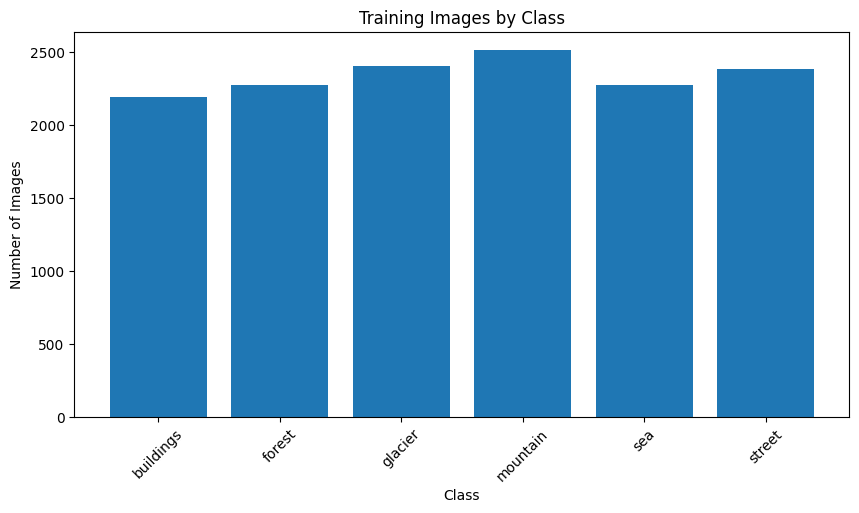

In [ ]:
import matplotlib.pyplot as plt
import os

classes = sorted([
    class_name
    for class_name in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, class_name))
])

train_counts = []

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    train_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(10, 5))
plt.bar(classes, train_counts)
plt.title("Training Images by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

Sample Images

Representative images from each class are displayed to visually inspect the types of scenes present in the dataset.

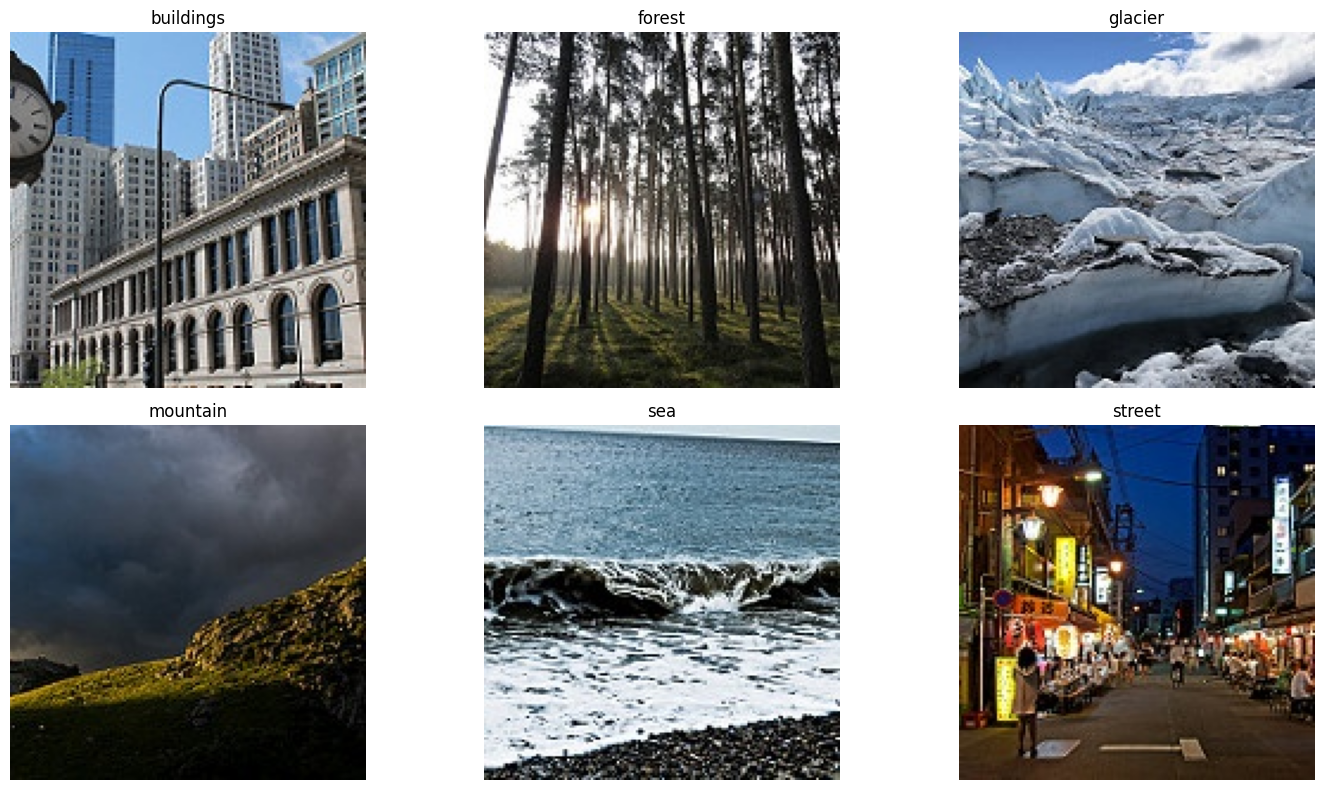

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_path, class_name)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import os

for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    print(class_name, ":", image.size)

buildings : (150, 150)
forest : (150, 150)
glacier : (150, 150)
mountain : (150, 150)
sea : (150, 150)
street : (150, 150)


Image Dimension Analysis

The original image dimensions are examined to determine an appropriate common input size for the CNN.

In [ ]:
import tensorflow as tf

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


 6. Data Preprocessing

The images are resized to 150 × 150 pixels. The training data is divided into training and validation subsets, while the separate test dataset is retained for final model evaluation.

A fixed random seed is used to make the train-validation split reproducible.

In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [ ]:
class_names = train_dataset.class_names

print("Class names:")
print(class_names)

Class names:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
print("Test classes:")
print(test_dataset.class_names)

Test classes:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


 Image Shape Verification

The shape of one batch of images is checked to confirm that the images are represented as RGB images with dimensions of 150 × 150 pixels.

In [ ]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 150, 150, 3)
Label batch shape: (32,)


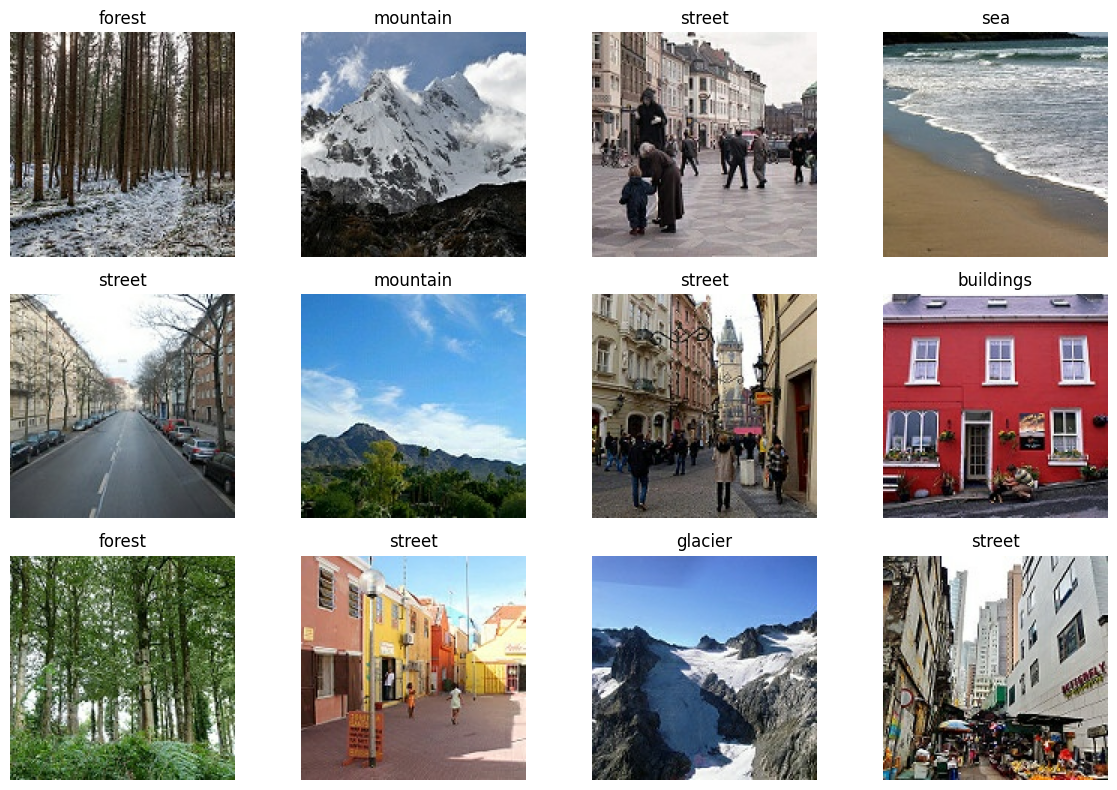

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

 Data Augmentation

Data augmentation is applied to improve the model's ability to generalize to unseen images. The augmentation pipeline includes:

- Horizontal flipping
- Random rotation
- Random zoom
- Random translation

These transformations create varied versions of training images without changing their class labels.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

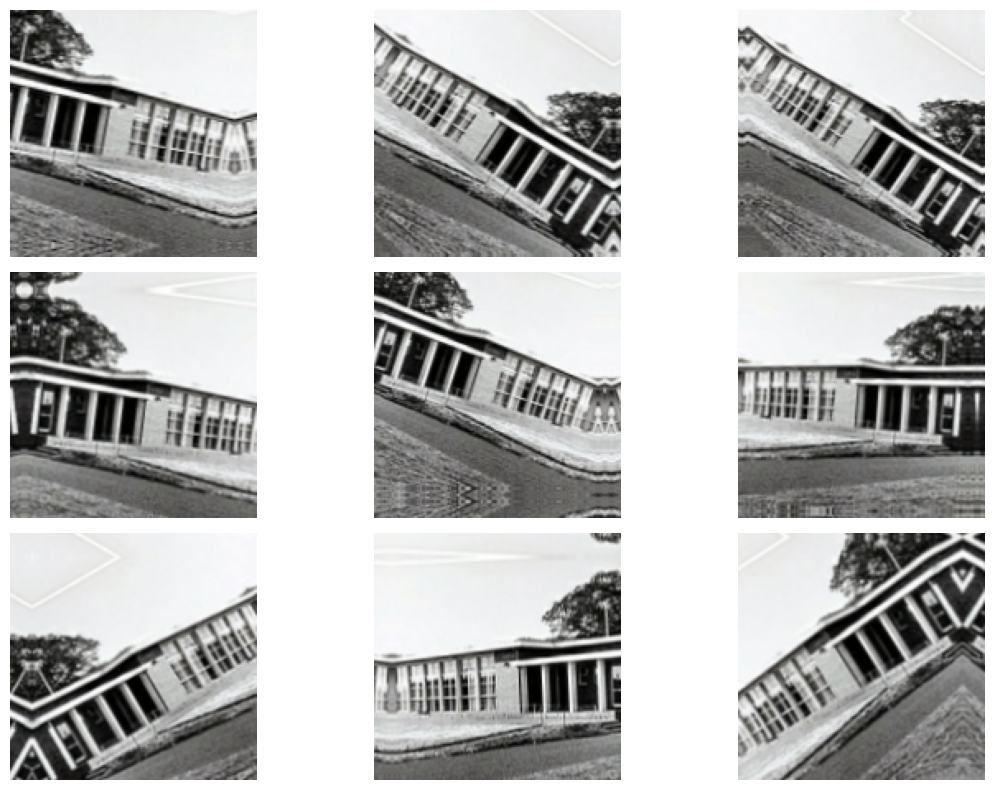

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    sample_image = images[0]

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("Datasets are ready for training.")

Datasets are ready for training.


7. CNN Model Development

A Convolutional Neural Network is developed from scratch for six-class image classification.
 CNN Architecture

The model consists of:

1. Input layer – 150 × 150 × 3
2. Data augmentation
3. Pixel normalization
4. Convolutional Layer 1 – 32 filters
5. Max Pooling
6. Convolutional Layer 2 – 64 filters
7. Max Pooling
8. Convolutional Layer 3 – 128 filters
9. Max Pooling
10. Flatten layer
11. Dense layer – 128 neurons
12. Dropout – 0.5
13. Output layer – 6 neurons with Softmax activation

ReLU activation is used in the convolutional and dense layers, while Softmax is used in the final output layer for six-class classification.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input layer
    layers.Input(shape=(150, 150, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification section
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    # Dropout for regularization
    layers.Dropout(0.5),

    # Six output classes
    layers.Dense(6, activation="softmax")
])

print("CNN model created successfully.")

CNN model created successfully.


Model Summary

The model summary below shows the architecture, output dimensions, and number of trainable parameters in each layer.

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

8. Model Compilation

The CNN is compiled using the Adam optimizer and sparse categorical crossentropy loss. Accuracy is used as the primary training metric.

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Training Callbacks

Early stopping is used to stop training when validation loss stops improving. Model checkpointing is used to save the model with the best validation accuracy.

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

9. CNN Model Training

The CNN is trained for a maximum of 20 epochs using the training dataset. Validation performance is monitored during training.

Early stopping is enabled to reduce unnecessary training and help prevent overfitting.

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[
        early_stopping,
        checkpoint
    ]
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.4946 - loss: 1.2583 - val_accuracy: 0.5524 - val_loss: 1.1970
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.6024 - loss: 1.0424 - val_accuracy: 0.6515 - val_loss: 0.9821
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6527 - loss: 0.9426 - val_accuracy: 0.7128 - val_loss: 0.7745
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6789 - loss: 0.8588 - val_accuracy: 0.6718 - val_loss: 0.9373
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7064 - loss: 0.8177 - val_accuracy: 0.7220 - val_loss: 0.7611
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7107 - loss: 0.7889 - val_accuracy: 0.7338 - val_loss: 0.7363
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7261 - loss: 0.7625 - val_accuracy: 0.7733 - val_loss: 0.6251
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7413 - loss: 0.7320 - 

In [ ]:
print("Training completed.")
print("Epochs actually completed:", len(history.history["loss"]))

Training completed.
Epochs actually completed: 17


In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


10. Training Performance

Training and Validation Accuracy

The training and validation accuracy curves are plotted to observe how classification performance changes across epochs and to identify potential overfitting or underfitting.

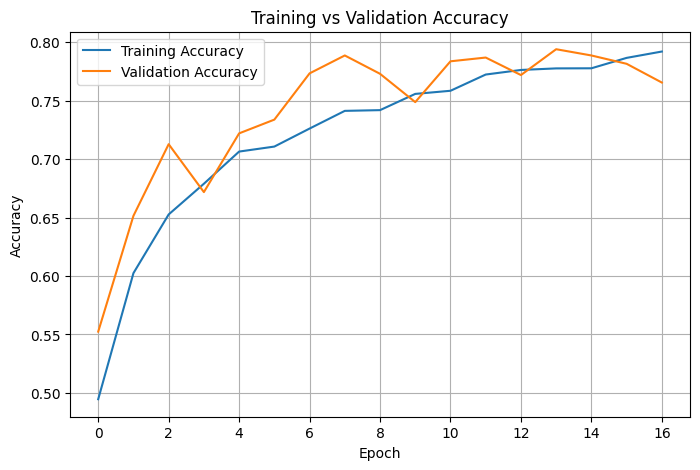

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

 Training and Validation Loss

The training and validation loss curves are plotted to examine how the model's prediction error changes during training.

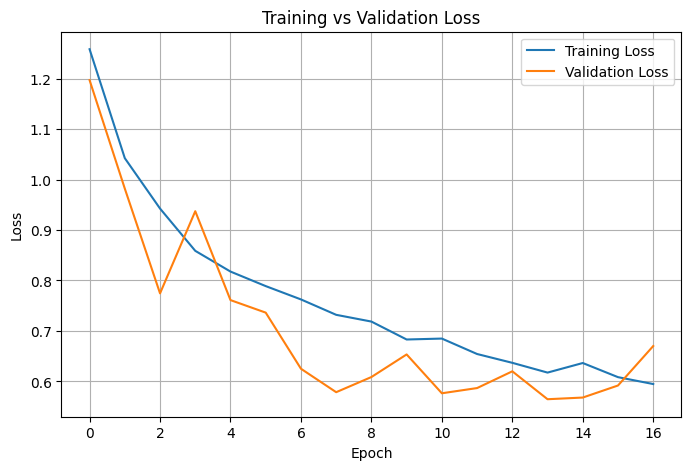

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

11. Model Evaluation on Test Data

After training, the model is evaluated using the independent test dataset. Test accuracy and test loss are calculated to measure the model's performance on unseen images.

In [ ]:
best_val_accuracy = max(history.history["val_accuracy"])
best_epoch = history.history["val_accuracy"].index(best_val_accuracy) + 1

print("Best Validation Accuracy:", best_val_accuracy)
print("Best Epoch:", best_epoch)

Best Validation Accuracy: 0.7940128445625305
Best Epoch: 14


In [ ]:
best_val_loss = min(history.history["val_loss"])
best_loss_epoch = history.history["val_loss"].index(best_val_loss) + 1

print("Best Validation Loss:", best_val_loss)
print("Best Loss Epoch:", best_loss_epoch)

Best Validation Loss: 0.5646958351135254
Best Loss Epoch: 14


In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.8007 - loss: 0.5752
Test Loss: 0.5752191543579102
Test Accuracy: 0.8006666898727417


Generating Test Predictions

Predictions are generated for all test images. The predicted class labels are compared with the actual labels for detailed evaluation.

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Actual labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

Actual labels: (3000,)
Predicted labels: (3000,)


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.8006666666666666


Classification Report

Precision, recall, and F1-score are calculated separately for each class to provide a detailed evaluation of classification performance.

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

   buildings       0.75      0.77      0.76       437
      forest       0.95      0.97      0.96       474
     glacier       0.83      0.71      0.76       553
    mountain       0.69      0.81      0.75       525
         sea       0.85      0.67      0.75       510
      street       0.78      0.89      0.83       501

    accuracy                           0.80      3000
   macro avg       0.81      0.80      0.80      3000
weighted avg       0.81      0.80      0.80      3000



Confusion Matrix

The confusion matrix is used to visualize correct and incorrect classifications across all six scene categories.

The diagonal values represent correctly classified images, while off-diagonal values represent misclassifications.

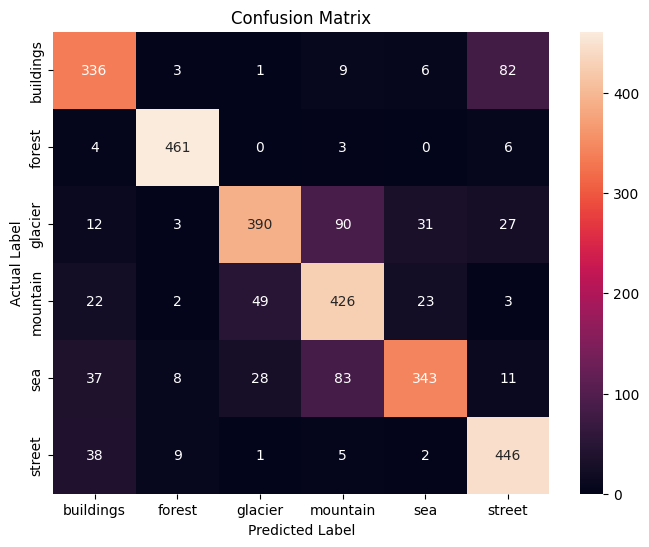

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Random Test Image Predictions

Ten random images from the test dataset are selected and classified using the trained CNN. The actual and predicted class labels are displayed for qualitative evaluation of the model.

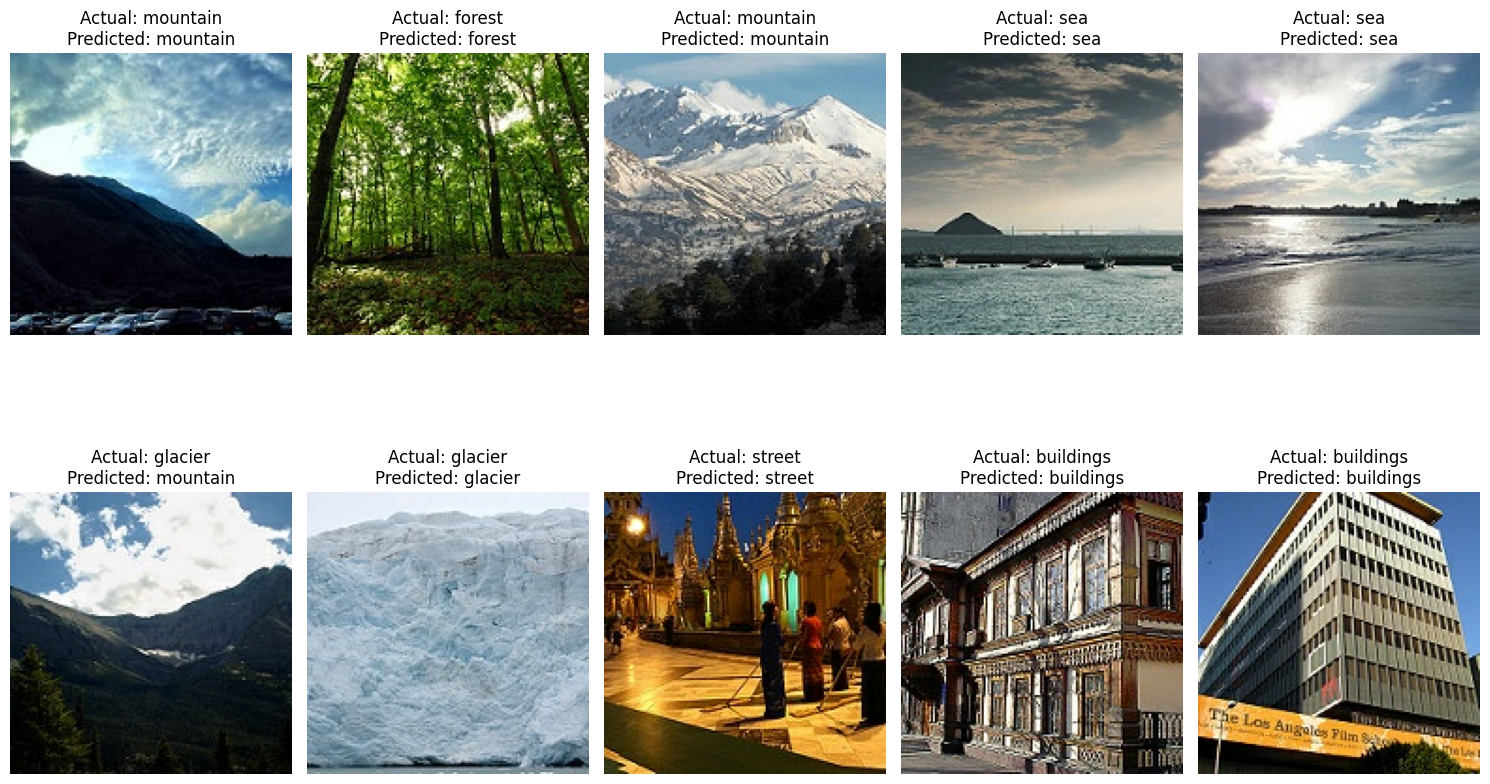

In [ ]:
import random
import matplotlib.pyplot as plt

# Collect test images and labels
all_test_images = []
all_test_labels = []

for images, labels in test_dataset:
    all_test_images.extend(images.numpy())
    all_test_labels.extend(labels.numpy())

all_test_images = np.array(all_test_images)
all_test_labels = np.array(all_test_labels)

# Select 10 random images
random_indices = random.sample(
    range(len(all_test_images)),
    10
)

plt.figure(figsize=(15, 10))

for i, index in enumerate(random_indices):

    image = all_test_images[index]
    actual_label = class_names[all_test_labels[index]]

    prediction = model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )

    predicted_index = np.argmax(prediction)
    predicted_label = class_names[predicted_index]

    plt.subplot(2, 5, i + 1)

    plt.imshow(image.astype("uint8"))

    plt.title(
        f"Actual: {actual_label}\n"
        f"Predicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

12. Saving the Trained Model

The trained CNN is saved in Keras format so that it can be reused for future predictions without retraining the model.

In [ ]:
model.save("CNN_Image_Classification.keras")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'intel-image-classification.zip', 'best_cnn_model.keras', 'intel_dataset', 'CNN_Image_Classification.keras', 'sample_data']


In [ ]:
import os

print("Current folder:")
print(os.getcwd())

print("\nKeras files:")
print([f for f in os.listdir("/content") if f.endswith(".keras")])

Current folder:
/content

Keras files:
['best_cnn_model.keras', 'CNN_Image_Classification.keras']


In [ ]:
!ls -lh *.keras

-rw-r--r-- 1 root root 56M Aug 25 11:24 best_cnn_model.keras
-rw-r--r-- 1 root root 56M Aug 25 11:31 CNN_Image_Classification.keras


 13. Conclusion

A Convolutional Neural Network was successfully developed to classify images from the Intel Image Classification dataset into six scene categories: buildings, forest, glacier, mountain, sea, and street.

The project included dataset exploration, image resizing, normalization, data augmentation, CNN model development, model training, and evaluation on an independent test dataset.

The final test accuracy achieved by the model was approximately 80.07%. Precision, recall, F1-score, confusion matrix analysis, and random test-image predictions were also used to evaluate the model in detail.

The results demonstrate that the CNN was able to learn useful visual features for natural scene classification and successfully generalize to unseen test images.